## Lab 09 : Implementation of Graph Neural Network for Node Classification

In [1]:
%%capture
import torch
version = torch.__version__
i = version.find('+')
version = version[:i-1] + '0' + version[i:]
url = 'https://data.pyg.org/whl/torch-' + version + '.html'

!pip install torch-scatter -f $url
!pip install torch-sparse -f $url
!pip install torch-geometric
!pip install torch-cluster -f $url
!pip install pygod
!pip install --upgrade scipy

In [2]:
# Importing Necessary Libraries :
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch_geometric.datasets import Amazon
import torch_geometric.transforms as T
import matplotlib.pyplot as plt
import torch.nn as nn
from torch_geometric.utils import to_networkx
import networkx as nx
from collections import Counter
from torch_geometric.data import Data

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing Dataset :
dataset = Amazon(root='./data', name='Computers')
graph = dataset[0]

In [4]:
# Showing Statistics of the dataset :
print("Dataset Stats :")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of nodes: {graph.num_nodes}")
print(f"Number of edges: {graph.num_edges}")
print(f"Number of node features: {dataset.num_node_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Is undirected: {graph.is_undirected()}")
print(f"Contains isolated nodes: {graph.contains_isolated_nodes()}")

Dataset Stats :
Number of graphs: 1
Number of nodes: 13752
Number of edges: 491722
Number of node features: 767
Number of classes: 10
Is undirected: True
Contains isolated nodes: True


In [5]:
# Printing Node Features of the data :
print("Node Features :")
print(graph.x)

Node Features :
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 1., 1., 0.]])


In [6]:
# Printing Edge Index of the data :
print("Edge Index (Transposed) :")
print(graph.edge_index.T)

Edge Index (Transposed) :
tensor([[    0,   507],
        [    0,  6551],
        [    0,  8210],
        ...,
        [13751, 12751],
        [13751, 13019],
        [13751, 13121]])


In [7]:
# Checking the class Distribution :
print("Class Distribution:")
print(sorted(Counter(graph.y.tolist()).items()))

Class Distribution:
[(0, 436), (1, 2142), (2, 1414), (3, 542), (4, 5158), (5, 308), (6, 487), (7, 818), (8, 2156), (9, 291)]


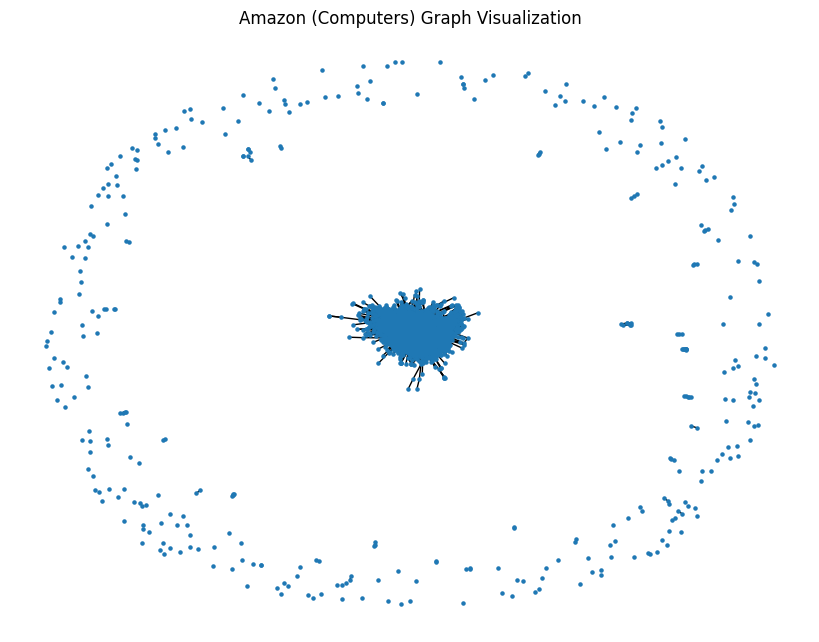

In [8]:
# Graphical Visualization :
def visualize_graph(graph):
    G = to_networkx(graph, to_undirected=True)
    plt.figure(figsize=(8, 6))
    nx.draw(G, node_size=5, with_labels=False)
    plt.title("Amazon (Computers) Graph Visualization")
    plt.show()

visualize_graph(graph)

In [9]:
# Train and Test Split :
split = T.RandomNodeSplit(num_val=0.1, num_test=0.2)
graph = split(graph)

print(f"train: {int(graph.train_mask.sum())}, ", f"val: {int(graph.val_mask.sum())}, ",f"test: {int(graph.test_mask.sum())}")

train: 9627,  val: 1375,  test: 2750


In [10]:
# Makig MLP Model for Node Classification :
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(dataset.num_node_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, dataset.num_classes)
        )

    def forward(self, data):
        x = data.x
        return self.layers(x)

In [11]:
# Training the Model :
def eval_node_classifier(model, graph, mask):
    model.eval()
    pred = model(graph).argmax(dim=1)
    correct = (pred[mask] == graph.y[mask]).sum()
    acc = int(correct) / int(mask.sum())
    return acc

def train_node_classifier(model, graph, optimizer, criterion, n_epochs=200):
    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(graph)
        loss = criterion(out[graph.train_mask], graph.y[graph.train_mask])
        loss.backward()
        optimizer.step()

        acc = eval_node_classifier(model, graph, graph.val_mask)

        if epoch % 10 == 0:
            print(f'Epoch: {epoch:03d}, Train Loss: {loss:.3f}, Val Acc: {acc:.3f}')
    return model

In [12]:
# Setup device and training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
graph = graph.to(device)
mlp = MLP().to(device)
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

In [13]:
# Train model
mlp = train_node_classifier(mlp, graph, optimizer_mlp, criterion, n_epochs=150)

Epoch: 010, Train Loss: 1.610, Val Acc: 0.505
Epoch: 020, Train Loss: 1.020, Val Acc: 0.693
Epoch: 030, Train Loss: 0.738, Val Acc: 0.780
Epoch: 040, Train Loss: 0.542, Val Acc: 0.801
Epoch: 050, Train Loss: 0.461, Val Acc: 0.830
Epoch: 060, Train Loss: 0.391, Val Acc: 0.836
Epoch: 070, Train Loss: 0.340, Val Acc: 0.841
Epoch: 080, Train Loss: 0.311, Val Acc: 0.832
Epoch: 090, Train Loss: 0.277, Val Acc: 0.839
Epoch: 100, Train Loss: 0.241, Val Acc: 0.845
Epoch: 110, Train Loss: 0.212, Val Acc: 0.836
Epoch: 120, Train Loss: 0.193, Val Acc: 0.830
Epoch: 130, Train Loss: 0.189, Val Acc: 0.821
Epoch: 140, Train Loss: 0.290, Val Acc: 0.779
Epoch: 150, Train Loss: 0.224, Val Acc: 0.828


In [14]:
# Evaluate on test set
test_acc = eval_node_classifier(mlp, graph, graph.test_mask)
print(f'\nTest Accuracy: {test_acc:.3f}')


Test Accuracy: 0.820
